In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

    !pip install -q ultralytics opencv-python matplotlib pandas
    from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

print("Setup successful!")

PyTorch version: 2.11.0+cu128
GPU available: True
GPU: Tesla T4
Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Setup successful!


In [ ]:
import os

os.makedirs("/content/road_damage/data", exist_ok=True)
os.makedirs("/content/road_damage/models", exist_ok=True)
os.makedirs("/content/road_damage/results", exist_ok=True)

print("Project directories created!")

Project directories created!


In [ ]:
import os

print("Current directory:")
print(os.getcwd())

print("\nGPU:")
import torch
print(torch.cuda.get_device_name(0))

Current directory:
/content

GPU:
Tesla T4


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")

print(model.names)

{0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza', 54: 'donut', 55: 'cake', 56: 'chair', 57: 'couch', 58: 'potted plant', 59: 'bed', 60: 'dining table', 61: 'toilet', 62: 'tv', 63: 'laptop', 64: 'mouse', 65: 'remote', 66: 'keyboard', 67: 'cell phone', 68: 'microw

In [ ]:
!pip install -q roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="OtqtVdCEZVt6juR96n7K")
project = rf.workspace("road-damage").project("rdd-dssrh")
version = project.version(1)
dataset = version.download("yolov11")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 302.8/302.8 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 61.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.9 MB/s eta 0:00:00
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to RDD-1 in yolov11:: 100%|██████████| 19788/19788 [00:02<00:00, 8563.85it/s]


In [ ]:
print(dataset.location)

/content/RDD-1


In [ ]:
import os

print("Dataset location:")
print(dataset.location)

print("\nFiles/Folders:")
print(os.listdir(dataset.location))

Dataset location:
/content/RDD-1

Files/Folders:
['README.dataset.txt', 'data.yaml', 'test', 'train', 'README.roboflow.txt', 'valid']


In [ ]:
import os

for root, dirs, files in os.walk(dataset.location):
    level = root.replace(dataset.location, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        dirs[:] = []

RDD-1/
  test/
    labels/
    images/
  train/
    labels/
    images/
  valid/
    labels/
    images/


In [ ]:
yaml_path = os.path.join(dataset.location, "data.yaml")

print(open(yaml_path).read())

train: ../train/images
val: ../valid/images
test: ../test/images

nc: 10
names: ['D00', 'D01', 'D0w0', 'D10', 'D11', 'D20', 'D40', 'D43', 'D44', 'D50']

roboflow:
  workspace: road-damage
  project: rdd-dssrh
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/road-damage/rdd-dssrh/dataset/1


Number of training images: 6922


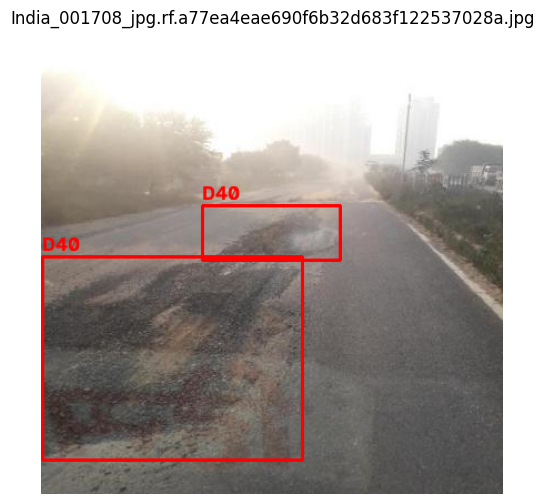

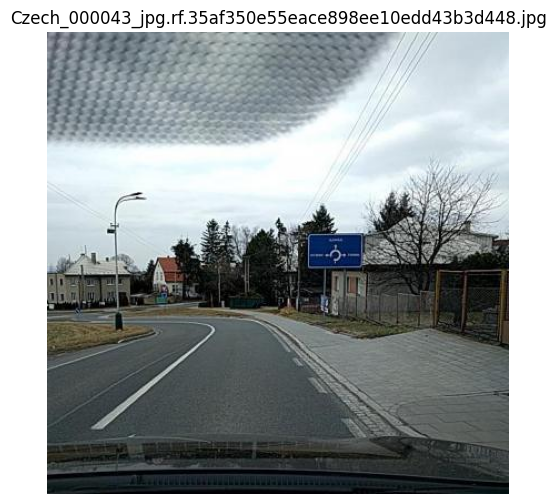

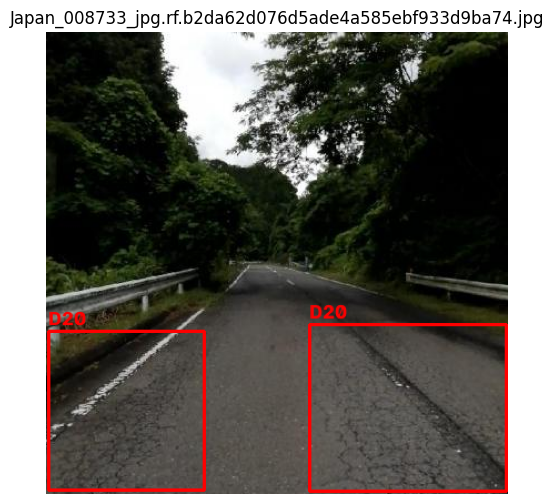

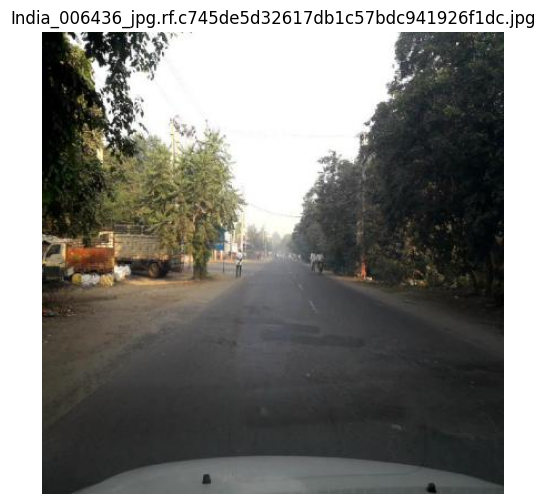

In [ ]:
from ultralytics import YOLO
import os
import random
import cv2
import matplotlib.pyplot as plt

train_images = os.path.join(dataset.location, "train", "images")
train_labels = os.path.join(dataset.location, "train", "labels")

image_files = [
    f for f in os.listdir(train_images)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("Number of training images:", len(image_files))

# Pick 4 random images
samples = random.sample(image_files, 4)

class_names = [
    'D00', 'D01', 'D0w0', 'D10', 'D11',
    'D20', 'D40', 'D43', 'D44', 'D50'
]

for img_file in samples:
    img_path = os.path.join(train_images, img_file)
    label_path = os.path.join(
        train_labels,
        os.path.splitext(img_file)[0] + ".txt"
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w, _ = img.shape

    if os.path.exists(label_path):
        with open(label_path, "r") as f:
            labels = f.readlines()

        for line in labels:
            parts = line.strip().split()

            if len(parts) != 5:
                continue

            class_id, x_center, y_center, box_w, box_h = map(float, parts)

            x1 = int((x_center - box_w / 2) * w)
            y1 = int((y_center - box_h / 2) * h)
            x2 = int((x_center + box_w / 2) * w)
            y2 = int((y_center + box_h / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

            label = class_names[int(class_id)]
            cv2.putText(
                img,
                label,
                (x1, max(y1 - 5, 15)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (255, 0, 0),
                2
            )

    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_file)
    plt.show()

In [ ]:
from ultralytics import YOLO

# Load pretrained YOLO11 Nano
model = YOLO("yolo11n.pt")

# Train on road-damage dataset
results = model.train(
    data="/content/RDD-1/data.yaml",
    epochs=25,
    imgsz=640,
    batch=16,
    device=0,
    patience=7,
    workers=2,
    project="/content/road_damage",
    name="road_damage_yolo11n"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_damage_yolo11n, nbs=64, nms=Fals

In [ ]:
from ultralytics import YOLO

best_model = YOLO(
    "/content/road_damage/road_damage_yolo11n/weights/best.pt"
)

metrics = best_model.val(
    data="/content/RDD-1/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("mAP50:", metrics.box.map50)
print("mAP50-95:", metrics.box.map)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 838.3±345.8 MB/s, size: 26.2 KB)
val: Scanning /content/RDD-1/test/labels... 989 images, 324 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 989/989 2.3Kit/s 0.4s
val: New cache created: /content/RDD-1/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 5.6it/s 11.1s
                   all        989       1581      0.595      0.457      0.441      0.231
                   D00        223        316      0.493      0.294      0.317       0.13
                   D01          2          5          1          0    0.00464   0.000929
                   D10        140        239      0.475      0.269      0.282      0.115
                   D20        320        399      0.532      0.511      0.479      0.

In [ ]:
test_results = best_model.predict(
    source="/content/RDD-1/test/images",
    conf=0.25,
    imgsz=640,
    device=0,
    save=True,
    project="/content/road_damage",
    name="test_predictions"
)

print("Predictions completed!")


image 1/989 /content/RDD-1/test/images/Czech_000014_jpg.rf.777aa543899d1a2e9ad46083ea244f62.jpg: 640x640 (no detections), 8.4ms
image 2/989 /content/RDD-1/test/images/Czech_000022_jpg.rf.d294c33735f196a6d6c54cf45dcebed0.jpg: 640x640 1 D10, 8.7ms
image 3/989 /content/RDD-1/test/images/Czech_000102_jpg.rf.6c6d703e6b5a1ad2c52ead2bf9e78b6f.jpg: 640x640 (no detections), 8.9ms
image 4/989 /content/RDD-1/test/images/Czech_000106_jpg.rf.b40ebd589215860391b167ea56c11fac.jpg: 640x640 (no detections), 8.5ms
image 5/989 /content/RDD-1/test/images/Czech_000117_jpg.rf.e38d1c1afd960a6fced2b98fd90475bf.jpg: 640x640 (no detections), 8.4ms
image 6/989 /content/RDD-1/test/images/Czech_000218_jpg.rf.e6663e0d1d6c449cc3e594ef3b48935e.jpg: 640x640 (no detections), 10.3ms
image 7/989 /content/RDD-1/test/images/Czech_000239_jpg.rf.f60b7a2b1227f59907c876ce7a94f952.jpg: 640x640 (no detections), 8.5ms
image 8/989 /content/RDD-1/test/images/Czech_000263_jpg.rf.6735d3377cc01809e27e455c81bd7211.jpg: 640x640 (no det

In [17]:
from ultralytics import YOLO

model2 = YOLO("yolo11n.pt")

results2 = model2.train(
    data="/content/RDD-1/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    patience=10,
    workers=2,

    # Augmentation
    degrees=5,
    translate=0.1,
    scale=0.5,
    fliplr=0.5,
    mosaic=1.0,

    project="/content/road_damage",
    name="road_damage_yolo11n_exp2"
)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/RDD-1/data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=road_damage_yolo11n_exp2, nbs=64, nms=F

In [18]:
from ultralytics import YOLO

best_model2 = YOLO(
    "/content/road_damage/road_damage_yolo11n_exp2/weights/best.pt"
)

metrics2 = best_model2.val(
    data="/content/RDD-1/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("Experiment 2 Test mAP50:", metrics2.box.map50)
print("Experiment 2 Test mAP50-95:", metrics2.box.map)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 914.5±414.0 MB/s, size: 25.4 KB)
val: Scanning /content/RDD-1/test/labels.cache... 989 images, 324 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 989/989 218.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 5.9it/s 10.4s
                   all        989       1581      0.515      0.439      0.456      0.221
                   D00        223        316      0.551      0.329      0.346      0.131
                   D01          2          5          0          0          0          0
                   D10        140        239      0.492      0.215      0.295      0.106
                   D20        320        399      0.571      0.516      0.512      0.235
                   D40        122        225 

In [19]:
print("Experiment 2 mAP50:", metrics2.box.map50)
print("Experiment 2 mAP50-95:", metrics2.box.map)
print("Per-class mAP50:", metrics2.box.ap50)
print("Per-class mAP50-95:", metrics2.box.ap)

Experiment 2 mAP50: 0.45559413599297716
Experiment 2 mAP50-95: 0.22118472050150947
Per-class mAP50: [    0.34574           0     0.29453     0.51151     0.37506     0.76002     0.56038      0.7975]
Per-class mAP50-95: [    0.13056           0     0.10574     0.23531     0.14602     0.43383     0.32111     0.39691]


In [20]:
test_results2 = best_model2.predict(
    source="/content/RDD-1/test/images",
    conf=0.25,
    imgsz=640,
    device=0,
    save=True,
    project="/content/road_damage",
    name="test_predictions_exp2"
)


image 1/989 /content/RDD-1/test/images/Czech_000014_jpg.rf.777aa543899d1a2e9ad46083ea244f62.jpg: 640x640 (no detections), 7.9ms
image 2/989 /content/RDD-1/test/images/Czech_000022_jpg.rf.d294c33735f196a6d6c54cf45dcebed0.jpg: 640x640 1 D10, 8.2ms
image 3/989 /content/RDD-1/test/images/Czech_000102_jpg.rf.6c6d703e6b5a1ad2c52ead2bf9e78b6f.jpg: 640x640 (no detections), 7.8ms
image 4/989 /content/RDD-1/test/images/Czech_000106_jpg.rf.b40ebd589215860391b167ea56c11fac.jpg: 640x640 (no detections), 8.1ms
image 5/989 /content/RDD-1/test/images/Czech_000117_jpg.rf.e38d1c1afd960a6fced2b98fd90475bf.jpg: 640x640 (no detections), 7.8ms
image 6/989 /content/RDD-1/test/images/Czech_000218_jpg.rf.e6663e0d1d6c449cc3e594ef3b48935e.jpg: 640x640 (no detections), 7.9ms
image 7/989 /content/RDD-1/test/images/Czech_000239_jpg.rf.f60b7a2b1227f59907c876ce7a94f952.jpg: 640x640 (no detections), 8.0ms
image 8/989 /content/RDD-1/test/images/Czech_000263_jpg.rf.6735d3377cc01809e27e455c81bd7211.jpg: 640x640 (no dete

In [21]:
import os

folder = "/content/road_damage/test_predictions_exp2"

files = os.listdir(folder)
print(files[:10])

['India_009072_jpg.rf.45bbbe4d1ffd4e46749f927fda382a51.jpg', 'Japan_011022_jpg.rf.bff500331dbb122f7fcd73648eb9d022.jpg', 'India_009487_jpg.rf.7dbee6a97bb0a8119a85b1d6ce7a9ee3.jpg', 'India_008029_jpg.rf.f029dd0862269e08ec6bdd8e9f8ec948.jpg', 'Japan_005477_jpg.rf.78771c6293a7e9220cb85670972d77e6.jpg', 'Japan_008348_jpg.rf.66b0f13f984cb9ec853bf60a43689578.jpg', 'Japan_002849_jpg.rf.799f17885f9bdd681b3e0acbfa4ffd10.jpg', 'India_006169_jpg.rf.f213ab7a702cae45b414821b981e54c4.jpg', 'India_003943_jpg.rf.f89fdc36f71bd190b50f91642fbe0608.jpg', 'India_005461_jpg.rf.044129e6401b4372833c776b62a80a63.jpg']


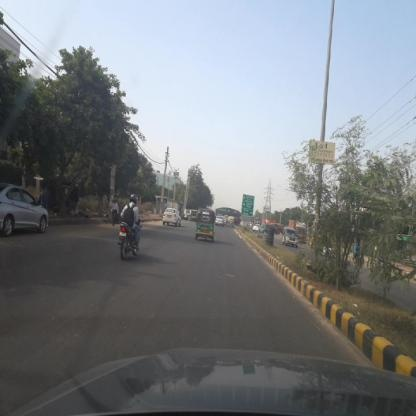

In [22]:
from IPython.display import Image, display

display(Image(
    filename="/content/road_damage/test_predictions_exp2/India_009072_jpg.rf.45bbbe4d1ffd4e46749f927fda382a51.jpg"
))

In [23]:
for r in test_results2:
    if len(r.boxes) > 0:
        print("Image:", r.path)
        print("Detections:", len(r.boxes))
        print("Classes:", r.boxes.cls.tolist())
        print("Confidence:", r.boxes.conf.tolist())
        break

Image: /content/RDD-1/test/images/Czech_000022_jpg.rf.d294c33735f196a6d6c54cf45dcebed0.jpg
Detections: 1
Classes: [3.0]
Confidence: [0.4823802411556244]


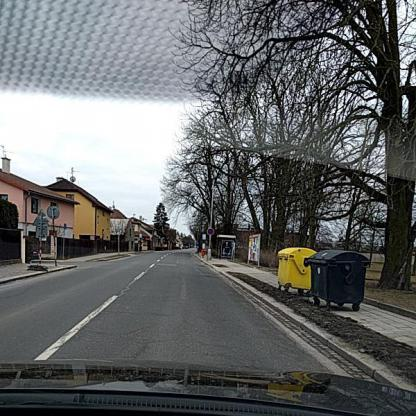

In [24]:
from IPython.display import Image, display

display(Image(filename=r.path))

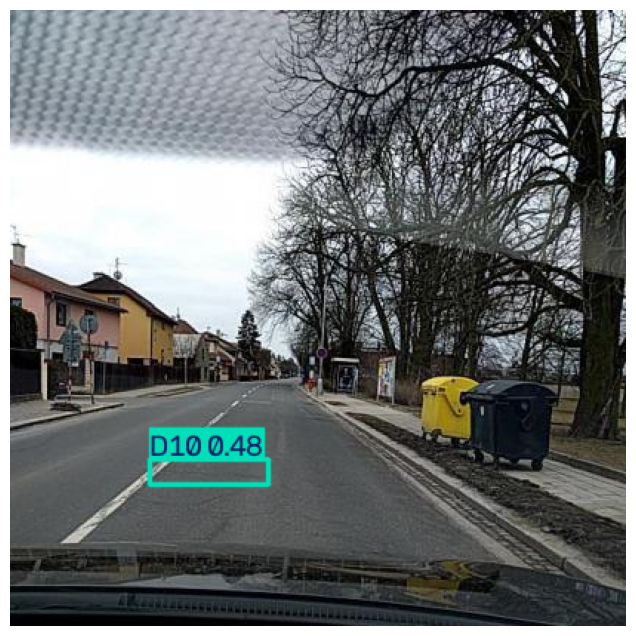

Image: /content/RDD-1/test/images/Czech_000022_jpg.rf.d294c33735f196a6d6c54cf45dcebed0.jpg
Detections: 1
Classes: [3.0]
Confidence: [0.4823802411556244]


In [25]:
from IPython.display import display
from PIL import Image
import matplotlib.pyplot as plt

for r in test_results2:
    if len(r.boxes) > 0:
        annotated = r.plot()

        plt.figure(figsize=(8, 8))
        plt.imshow(annotated[:, :, ::-1])
        plt.axis("off")
        plt.show()

        print("Image:", r.path)
        print("Detections:", len(r.boxes))
        print("Classes:", r.boxes.cls.tolist())
        print("Confidence:", r.boxes.conf.tolist())
        break

In [26]:
from ultralytics import YOLO

best_model2 = YOLO(
    "/content/road_damage/road_damage_yolo11n_exp2/weights/best.pt"
)

metrics2 = best_model2.val(
    data="/content/RDD-1/data.yaml",
    split="test",
    imgsz=640,
    batch=16,
    device=0,
    plots=True
)

print("mAP50:", metrics2.box.map50)
print("mAP50-95:", metrics2.box.map)

Ultralytics 8.4.138 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 101 layers, 2,584,102 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 763.9±223.6 MB/s, size: 30.7 KB)
val: Scanning /content/RDD-1/test/labels.cache... 989 images, 324 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 989/989 188.6Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 6.2it/s 9.9s
                   all        989       1581      0.515      0.439      0.456      0.221
                   D00        223        316      0.551      0.329      0.346      0.131
                   D01          2          5          0          0          0          0
                   D10        140        239      0.492      0.215      0.295      0.106
                   D20        320        399      0.571      0.516      0.512      0.235
                   D40        122        225  

In [27]:
import os

folder = "/content/road_damage"

for root, dirs, files in os.walk(folder):
    for file in files:
        if "confusion" in file.lower() or "results.png" in file.lower():
            print(os.path.join(root, file))

/content/road_damage/road_damage_yolo11n_exp2/confusion_matrix_normalized.png
/content/road_damage/road_damage_yolo11n_exp2/confusion_matrix.png
/content/road_damage/road_damage_yolo11n_exp2/results.png
/content/road_damage/road_damage_yolo11n/confusion_matrix_normalized.png
/content/road_damage/road_damage_yolo11n/confusion_matrix.png
/content/road_damage/road_damage_yolo11n/results.png


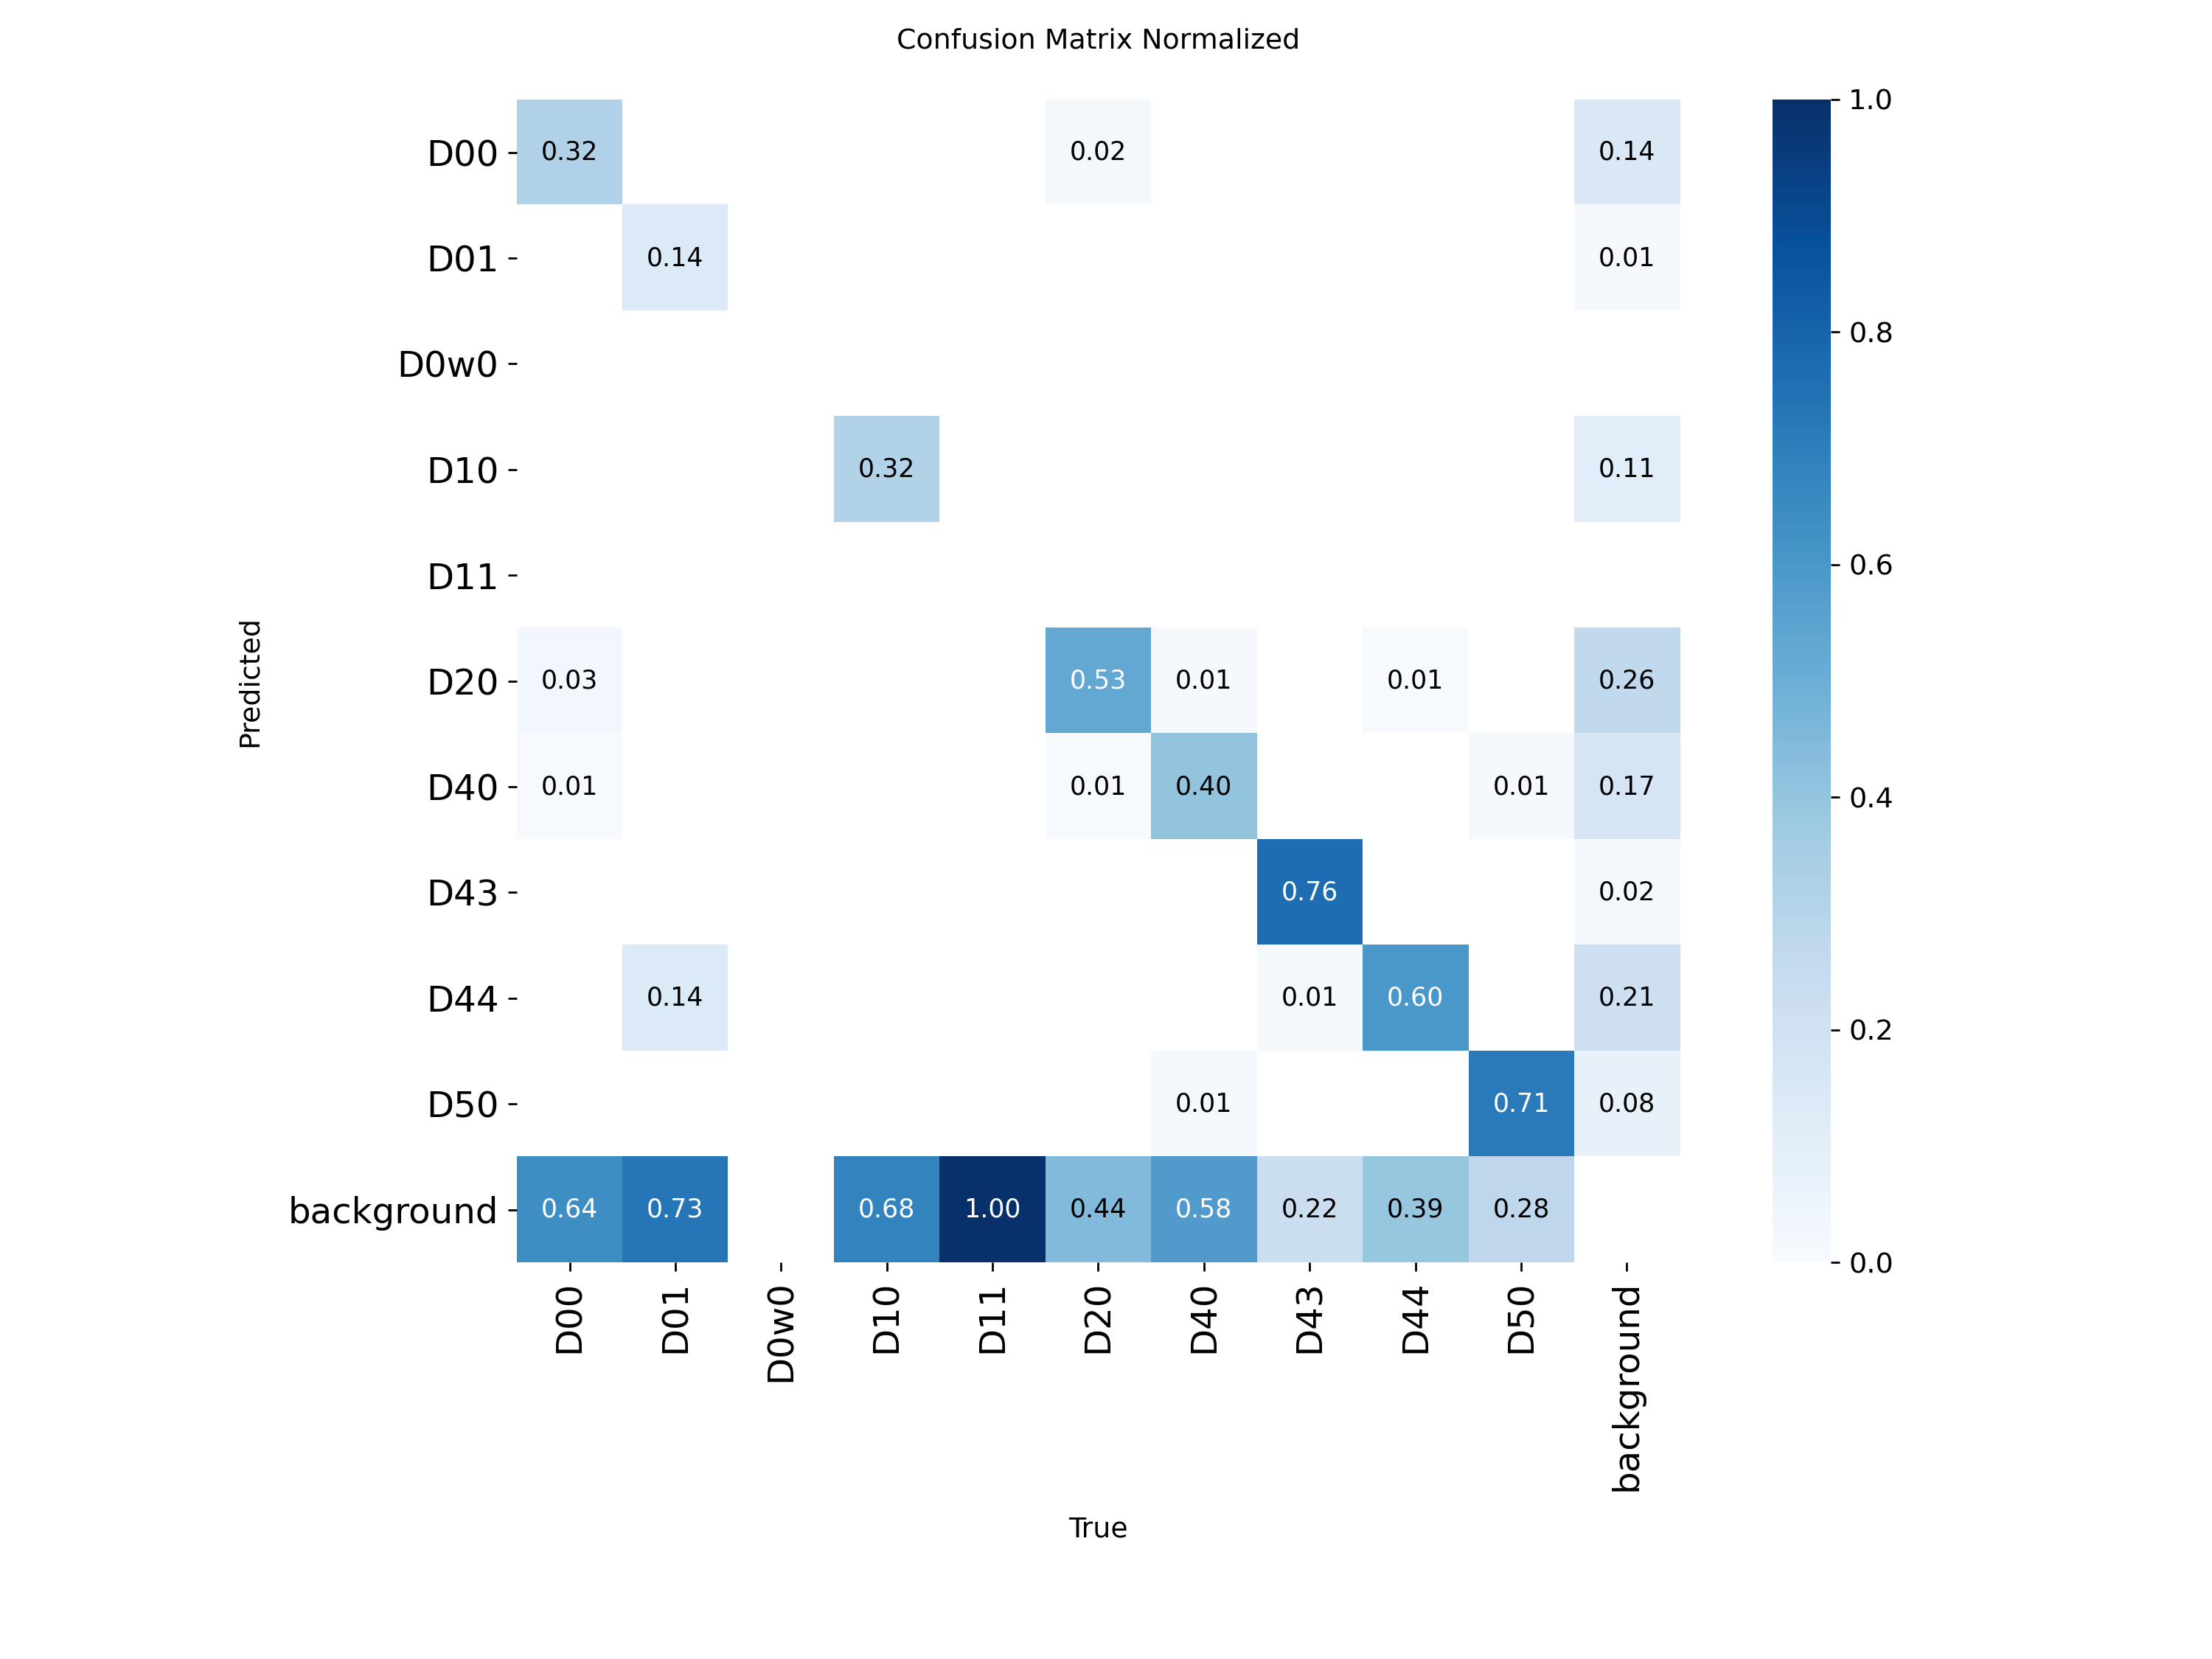

In [28]:
from IPython.display import display
from PIL import Image

display(Image.open(
    "/content/road_damage/road_damage_yolo11n_exp2/confusion_matrix_normalized.png"
))

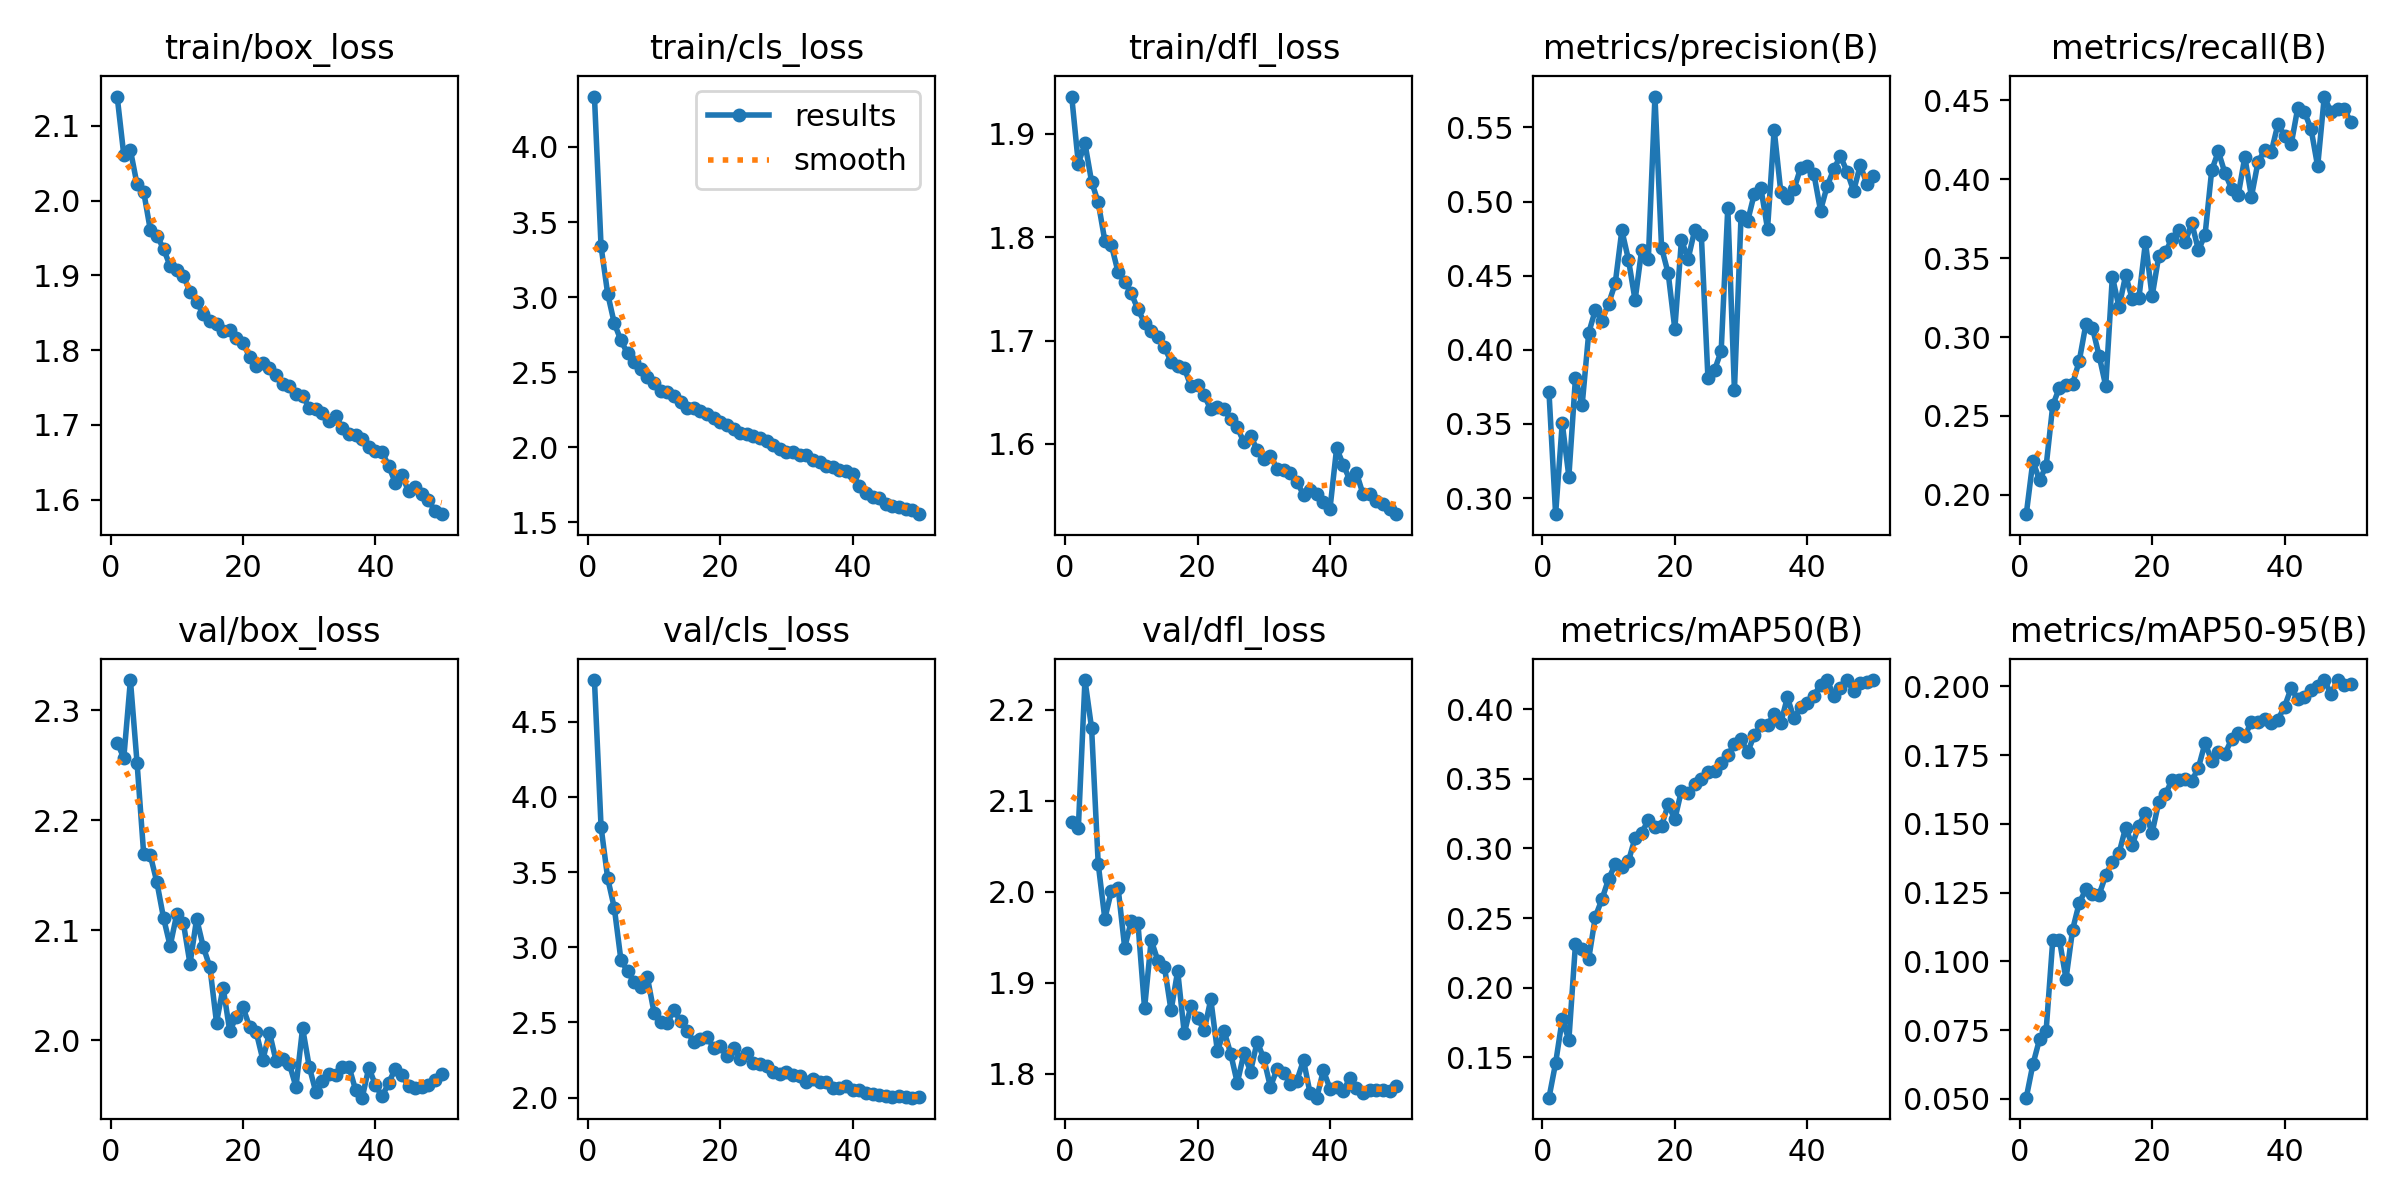

In [29]:
from IPython.display import display
from PIL import Image

display(Image.open(
    "/content/road_damage/road_damage_yolo11n_exp2/results.png"
))